# D'Hondt Proportional Representation Visualizer

This interactive notebook demonstrates how the D'Hondt method allocates seats in proportional representation elections.

## What is D'Hondt?

The D'Hondt method is an electoral system that allocates seats proportionally based on vote counts. It works by:
1. Calculating each party's quotient: `votes / (seats_allocated + 1)`
2. Awarding one seat to the party with the highest quotient
3. Repeating until all seats are distributed

The genius: **It stays entirely in the integer domain** - no fractional seats to round!

In [1]:
# Import libraries
import sys
sys.path.append('src')
from main import DHondt
import ipywidgets as widgets
from IPython.display import display, HTML
import plotly.graph_objects as go
import plotly.express as px
import pandas as pd

{'Party A': 48, 'Party B': 38, 'Party C': 14}


## Interactive D'Hondt Simulator

Use the sliders below to adjust vote counts and total seats, then see how seats are allocated!

In [2]:
# Create interactive widgets
votes_a = widgets.IntSlider(value=100000, min=10000, max=200000, step=5000, description='Party A Votes:')
votes_b = widgets.IntSlider(value=80000, min=10000, max=200000, step=5000, description='Party B Votes:')
votes_c = widgets.IntSlider(value=30000, min=10000, max=200000, step=5000, description='Party C Votes:')
total_seats = widgets.IntSlider(value=10, min=5, max=200, step=5, description='Total Seats:')

output = widgets.Output()

def update_visualization(change):
    with output:
        output.clear_output(wait=True)
        
        # Run D'Hondt algorithm
        parties = ['Party A', 'Party B', 'Party C']
        votes = {'Party A': votes_a.value, 'Party B': votes_b.value, 'Party C': votes_c.value}
        
        dhondt = DHondt(parties=parties, votes=votes, total_seats=total_seats.value)
        dhondt.dhondt()
        
        # Calculate vote and seat percentages
        total_votes = sum(votes.values())
        vote_pcts = {p: (v / total_votes * 100) for p, v in votes.items()}
        seat_pcts = {p: (s / total_seats.value * 100) for p, s in dhondt._seat_allocation.items()}
        
        # Create visualization
        fig = go.Figure()
        
        # Add bars for vote share vs seat share
        fig.add_trace(go.Bar(
            name='Vote Share (%)',
            x=parties,
            y=[vote_pcts[p] for p in parties],
            marker_color='lightblue',
            text=[f"{vote_pcts[p]:.2f}%" for p in parties],
            textposition='outside'
        ))
        
        fig.add_trace(go.Bar(
            name='Seat Share (%)',
            x=parties,
            y=[seat_pcts[p] for p in parties],
            marker_color='coral',
            text=[f"{seat_pcts[p]:.2f}%<br>({dhondt._seat_allocation[p]} seats)" for p in parties],
            textposition='outside'
        ))
        
        fig.update_layout(
            title='Vote Share vs. Seat Share',
            xaxis_title='Party',
            yaxis_title='Percentage',
            barmode='group',
            height=500
        )
        
        display(fig)
        
        # Display seat allocation table
        df = pd.DataFrame({
            'Party': parties,
            'Votes': [votes[p] for p in parties],
            'Vote %': [f"{vote_pcts[p]:.2f}%" for p in parties],
            'Seats': [dhondt._seat_allocation[p] for p in parties],
            'Seat %': [f"{seat_pcts[p]:.2f}%" for p in parties],
            'Difference': [f"{seat_pcts[p] - vote_pcts[p]:+.2f}%" for p in parties]
        })
        
        print("\n" + "="*80)
        print("SEAT ALLOCATION RESULTS")
        print("="*80)
        print(df.to_string(index=False))
        print("\n💡 Difference shows how much each party's seat share differs from their vote share.")
        print("   D'Hondt tends to slightly favor larger parties.")

# Attach update function to all widgets
votes_a.observe(update_visualization, 'value')
votes_b.observe(update_visualization, 'value')
votes_c.observe(update_visualization, 'value')
total_seats.observe(update_visualization, 'value')

# Display widgets
display(votes_a, votes_b, votes_c, total_seats, output)

# Initial update
update_visualization(None)

IntSlider(value=100000, description='Party A Votes:', max=200000, min=10000, step=5000)

IntSlider(value=80000, description='Party B Votes:', max=200000, min=10000, step=5000)

IntSlider(value=30000, description='Party C Votes:', max=200000, min=10000, step=5000)

IntSlider(value=10, description='Total Seats:', max=200, min=5, step=5)

Output()

## Step-by-Step Allocation Trace

Want to see exactly how each seat gets allocated? Run this cell to trace through the algorithm round-by-round.

In [3]:
def trace_dhondt_allocation(parties, votes, total_seats):
    """Show step-by-step allocation process"""
    seat_allocation = {party: 0 for party in parties}
    
    print("🗳️  D'HONDT ALLOCATION TRACE")
    print("="*80)
    print(f"\nInitial Votes: {votes}")
    print(f"Total Seats to Allocate: {total_seats}\n")
    
    for round_num in range(1, total_seats + 1):
        # Calculate quotients
        quotients = {}
        for party in parties:
            seats = seat_allocation[party]
            quotient = votes[party] / (seats + 1)
            quotients[party] = quotient
        
        # Find winner
        winner = max(quotients, key=quotients.get)
        seat_allocation[winner] += 1
        
        # Display round info
        print(f"Round {round_num}:")
        for party in parties:
            seats = seat_allocation[party] - (1 if party == winner else 0)
            indicator = "👉 WINS SEAT" if party == winner else ""
            print(f"  {party}: {votes[party]:,} / ({seats}+1) = {quotients[party]:,.2f} {indicator}")
        print(f"  Current allocation: {seat_allocation}\n")
    
    print("="*80)
    print(f"\n✅ FINAL ALLOCATION: {seat_allocation}")
    
    # Show proportionality
    total_votes = sum(votes.values())
    print("\n📊 Proportionality Check:")
    for party in parties:
        vote_pct = votes[party] / total_votes * 100
        seat_pct = seat_allocation[party] / total_seats * 100
        diff = seat_pct - vote_pct
        print(f"  {party}: {vote_pct:.2f}% votes → {seat_pct:.2f}% seats (diff: {diff:+.2f}%)")

# Example trace
trace_dhondt_allocation(
    parties=['Party A', 'Party B', 'Party C'],
    votes={'Party A': 100000, 'Party B': 80000, 'Party C': 30000},
    total_seats=10
)

🗳️  D'HONDT ALLOCATION TRACE

Initial Votes: {'Party A': 100000, 'Party B': 80000, 'Party C': 30000}
Total Seats to Allocate: 10

Round 1:
  Party A: 100,000 / (0+1) = 100,000.00 👉 WINS SEAT
  Party B: 80,000 / (0+1) = 80,000.00 
  Party C: 30,000 / (0+1) = 30,000.00 
  Current allocation: {'Party A': 1, 'Party B': 0, 'Party C': 0}

Round 2:
  Party A: 100,000 / (1+1) = 50,000.00 
  Party B: 80,000 / (0+1) = 80,000.00 👉 WINS SEAT
  Party C: 30,000 / (0+1) = 30,000.00 
  Current allocation: {'Party A': 1, 'Party B': 1, 'Party C': 0}

Round 3:
  Party A: 100,000 / (1+1) = 50,000.00 👉 WINS SEAT
  Party B: 80,000 / (1+1) = 40,000.00 
  Party C: 30,000 / (0+1) = 30,000.00 
  Current allocation: {'Party A': 2, 'Party B': 1, 'Party C': 0}

Round 4:
  Party A: 100,000 / (2+1) = 33,333.33 
  Party B: 80,000 / (1+1) = 40,000.00 👉 WINS SEAT
  Party C: 30,000 / (0+1) = 30,000.00 
  Current allocation: {'Party A': 2, 'Party B': 2, 'Party C': 0}

Round 5:
  Party A: 100,000 / (2+1) = 33,333.33 👉 WIN

## 🎬 Animated Seat Allocation

Watch seats being allocated in real-time! Click the button below to see the D'Hondt algorithm in action, round by round.

In [ ]:
import time
from IPython.display import clear_output

def animate_dhondt_allocation(parties, votes, total_seats, delay=0.5):
    """Animate seat allocation round-by-round"""
    seat_allocation = {party: 0 for party in parties}
    total_votes = sum(votes.values())
    
    print("🎬 ANIMATED D'HONDT ALLOCATION")
    print("="*80)
    print(f"Initial Votes: {votes}")
    print(f"Total Seats: {total_seats}\n")
    print("Starting in 2 seconds...\n")
    time.sleep(2)
    
    for round_num in range(1, total_seats + 1):
        clear_output(wait=True)
        
        # Calculate quotients
        quotients = {}
        for party in parties:
            seats = seat_allocation[party]
            quotient = votes[party] / (seats + 1)
            quotients[party] = quotient
        
        # Find winner
        winner = max(quotients, key=quotients.get)
        
        # Display current state BEFORE allocation
        print("🎬 ANIMATED D'HONDT ALLOCATION")
        print("="*80)
        print(f"\nRound {round_num} of {total_seats}")
        print("\nCurrent Quotients (votes / seats+1):")
        print("-" * 80)
        
        for party in parties:
            seats = seat_allocation[party]
            q = quotients[party]
            indicator = "  👉 WINS THIS SEAT!" if party == winner else ""
            print(f"{party:12s}: {votes[party]:8,} / ({seats}+1) = {q:10,.2f}{indicator}")
        
        # Allocate the seat
        seat_allocation[winner] += 1
        
        # Show updated allocation
        print("\n" + "-" * 80)
        print("Current Seat Allocation:")
        print("-" * 80)
        
        # Create visual bar representation
        max_bar_width = 50
        max_seats = max(seat_allocation.values()) if seat_allocation else 1
        
        for party in parties:
            seats = seat_allocation[party]
            vote_pct = votes[party] / total_votes * 100
            seat_pct = seats / total_seats * 100 if total_seats > 0 else 0
            bar_length = int((seats / total_seats) * max_bar_width) if total_seats > 0 else 0
            bar = "█" * bar_length
            
            print(f"{party:12s}: {bar} {seats:2d} seats ({seat_pct:5.1f}% | votes: {vote_pct:5.1f}%)")
        
        print("\n" + "="*80)
        
        # Pause before next round
        time.sleep(delay)
    
    # Final summary
    print("\n" + "🎉" * 40)
    print("\n✅ ALLOCATION COMPLETE!\n")
    print("Final Results:")
    print("-" * 80)
    
    for party in parties:
        seats = seat_allocation[party]
        vote_pct = votes[party] / total_votes * 100
        seat_pct = seats / total_seats * 100
        diff = seat_pct - vote_pct
        print(f"{party:12s}: {seats:2d} seats ({seat_pct:5.1f}%) | "
              f"Votes: {vote_pct:5.1f}% | Diff: {diff:+5.1f}%")

# Create interactive button
animate_button = widgets.Button(
    description='🎬 Animate Allocation!',
    button_style='success',
    tooltip='Watch seats being allocated round-by-round',
    icon='play'
)

animation_output = widgets.Output()

def on_animate_click(b):
    with animation_output:
        animation_output.clear_output()
        animate_dhondt_allocation(
            parties=['Party A', 'Party B', 'Party C'],
            votes={'Party A': 100000, 'Party B': 80000, 'Party C': 30000},
            total_seats=10,
            delay=0.8  # 0.8 seconds between rounds
        )

animate_button.on_click(on_animate_click)

display(animate_button, animation_output)

print("\n💡 Tip: Click the button above to start the animation!")
print("   You'll see each seat being allocated one-by-one with quotient calculations.")

## Experiment: How Does Legislature Size Affect Proportionality?

One insight: **larger legislatures produce more proportional results**. Let's see this in action!

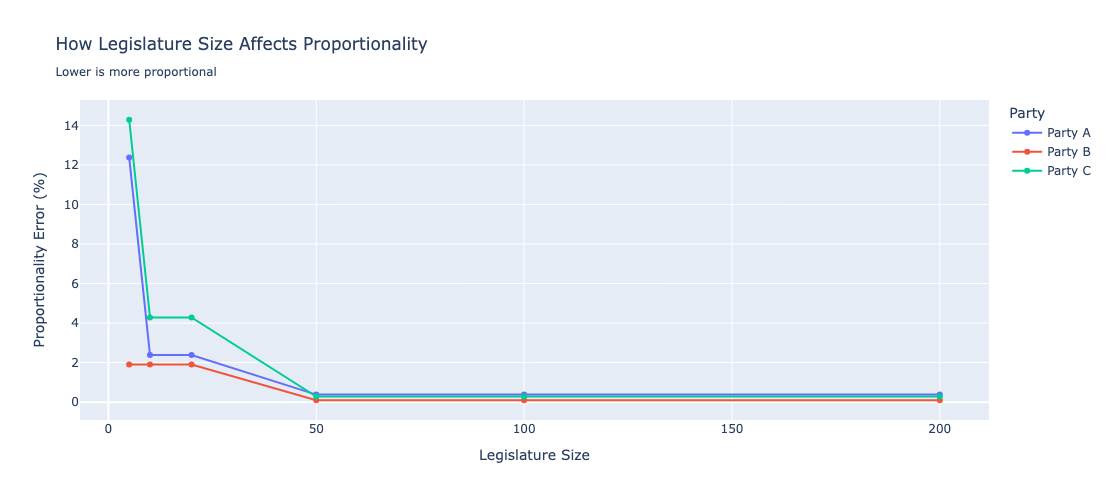


💡 Key Insight: With 5 seats, Party C gets 0% (vs 14.29% vote share = 14.29% error).
   With 200 seats, Party C gets 14% (vs 14.29% vote share = 0.29% error).
   This is why national parliaments have hundreds of seats!


In [4]:
def compare_legislature_sizes():
    """Show how proportionality improves with more seats"""
    parties = ['Party A', 'Party B', 'Party C']
    votes = {'Party A': 100000, 'Party B': 80000, 'Party C': 30000}
    total_votes = sum(votes.values())
    
    legislature_sizes = [5, 10, 20, 50, 100, 200]
    results = []
    
    for size in legislature_sizes:
        dhondt = DHondt(parties=parties, votes=votes, total_seats=size)
        dhondt.dhondt()
        
        for party in parties:
            vote_pct = votes[party] / total_votes * 100
            seat_pct = dhondt._seat_allocation[party] / size * 100
            diff = abs(seat_pct - vote_pct)
            
            results.append({
                'Legislature Size': size,
                'Party': party,
                'Proportionality Error (%)': diff
            })
    
    df = pd.DataFrame(results)
    
    # Plot
    fig = px.line(
        df, 
        x='Legislature Size', 
        y='Proportionality Error (%)',
        color='Party',
        title='How Legislature Size Affects Proportionality<br><sub>Lower is more proportional</sub>',
        markers=True
    )
    
    fig.update_layout(height=500)
    display(fig)
    
    print("\n💡 Key Insight: With 5 seats, Party C gets 0% (vs 14.29% vote share = 14.29% error).")
    print("   With 200 seats, Party C gets 14% (vs 14.29% vote share = 0.29% error).")
    print("   This is why national parliaments have hundreds of seats!")

compare_legislature_sizes()

## 🎯 Try Your Own Scenarios!

Edit the cells below to test different scenarios:

In [5]:
# Scenario 1: Very close race
trace_dhondt_allocation(
    parties=['Party A', 'Party B', 'Party C'],
    votes={'Party A': 100000, 'Party B': 99000, 'Party C': 98000},
    total_seats=10
)

🗳️  D'HONDT ALLOCATION TRACE

Initial Votes: {'Party A': 100000, 'Party B': 99000, 'Party C': 98000}
Total Seats to Allocate: 10

Round 1:
  Party A: 100,000 / (0+1) = 100,000.00 👉 WINS SEAT
  Party B: 99,000 / (0+1) = 99,000.00 
  Party C: 98,000 / (0+1) = 98,000.00 
  Current allocation: {'Party A': 1, 'Party B': 0, 'Party C': 0}

Round 2:
  Party A: 100,000 / (1+1) = 50,000.00 
  Party B: 99,000 / (0+1) = 99,000.00 👉 WINS SEAT
  Party C: 98,000 / (0+1) = 98,000.00 
  Current allocation: {'Party A': 1, 'Party B': 1, 'Party C': 0}

Round 3:
  Party A: 100,000 / (1+1) = 50,000.00 
  Party B: 99,000 / (1+1) = 49,500.00 
  Party C: 98,000 / (0+1) = 98,000.00 👉 WINS SEAT
  Current allocation: {'Party A': 1, 'Party B': 1, 'Party C': 1}

Round 4:
  Party A: 100,000 / (1+1) = 50,000.00 👉 WINS SEAT
  Party B: 99,000 / (1+1) = 49,500.00 
  Party C: 98,000 / (1+1) = 49,000.00 
  Current allocation: {'Party A': 2, 'Party B': 1, 'Party C': 1}

Round 5:
  Party A: 100,000 / (2+1) = 33,333.33 
  Pa

In [6]:
# Scenario 2: Landslide with small party
trace_dhondt_allocation(
    parties=['Party A', 'Party B', 'Party C', 'Party D'],
    votes={'Party A': 150000, 'Party B': 40000, 'Party C': 15000, 'Party D': 5000},
    total_seats=20
)

🗳️  D'HONDT ALLOCATION TRACE

Initial Votes: {'Party A': 150000, 'Party B': 40000, 'Party C': 15000, 'Party D': 5000}
Total Seats to Allocate: 20

Round 1:
  Party A: 150,000 / (0+1) = 150,000.00 👉 WINS SEAT
  Party B: 40,000 / (0+1) = 40,000.00 
  Party C: 15,000 / (0+1) = 15,000.00 
  Party D: 5,000 / (0+1) = 5,000.00 
  Current allocation: {'Party A': 1, 'Party B': 0, 'Party C': 0, 'Party D': 0}

Round 2:
  Party A: 150,000 / (1+1) = 75,000.00 👉 WINS SEAT
  Party B: 40,000 / (0+1) = 40,000.00 
  Party C: 15,000 / (0+1) = 15,000.00 
  Party D: 5,000 / (0+1) = 5,000.00 
  Current allocation: {'Party A': 2, 'Party B': 0, 'Party C': 0, 'Party D': 0}

Round 3:
  Party A: 150,000 / (2+1) = 50,000.00 👉 WINS SEAT
  Party B: 40,000 / (0+1) = 40,000.00 
  Party C: 15,000 / (0+1) = 15,000.00 
  Party D: 5,000 / (0+1) = 5,000.00 
  Current allocation: {'Party A': 3, 'Party B': 0, 'Party C': 0, 'Party D': 0}

Round 4:
  Party A: 150,000 / (3+1) = 37,500.00 
  Party B: 40,000 / (0+1) = 40,000.00 